<a href="https://colab.research.google.com/github/saravana113217/hospital/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving automobile_dot_it_used_fiat_500_in_Italy_dataset_filtered.csv to automobile_dot_it_used_fiat_500_in_Italy_dataset_filtered.csv


In [ ]:
df = pd.read_csv("/content/automobile_dot_it_used_fiat_500_in_Italy_dataset_filtered.csv")

In [ ]:
df.head(10)

,model,engine_power,age_in_days,km,previous_owners,lat,lon,price
0,lounge,51,882,25000,1,44.907242,8.611560,8900
1,pop,51,1186,32500,1,45.666359,12.241890,8800
2,sport,74,4658,142228,1,45.503300,11.417840,4200
3,lounge,51,2739,160000,1,40.633171,17.634609,6000
4,pop,73,3074,106880,1,41.903221,12.495650,5700
5,pop,74,3623,70225,1,45.000702,7.682270,7900
6,lounge,51,731,11600,1,44.907242,8.611560,10750
7,lounge,51,1521,49076,1,41.903221,12.495650,9190
8,sport,73,4049,76000,1,45.548000,11.549470,5600
9,sport,51,3653,89000,1,45.438301,10.991700,6000


In [ ]:
print(df['price'].min())
print(df['price'].max())

2500
11100


In [ ]:
print(df['price'].describe())

count     1538.000000
mean      8576.003901
std       1939.958641
min       2500.000000
25%       7122.500000
50%       9000.000000
75%      10000.000000
max      11100.000000
Name: price, dtype: float64


In [ ]:
bins = [0, 7000, 9000, 11000]

labels = ['Low', 'Medium', 'High']

df['Price_Class'] = pd.cut(
    df['price'],
    bins=bins,
    labels=labels
)

In [ ]:
df.head()

,model,engine_power,age_in_days,km,previous_owners,lat,lon,price,Price_Class
0,lounge,51,882,25000,1,44.907242,8.611560,8900,Medium
1,pop,51,1186,32500,1,45.666359,12.241890,8800,Medium
2,sport,74,4658,142228,1,45.503300,11.417840,4200,Low
3,lounge,51,2739,160000,1,40.633171,17.634609,6000,Low
4,pop,73,3074,106880,1,41.903221,12.495650,5700,Low


In [ ]:
X = df.drop(['price', 'Price_Class'], axis=1)
y = df['Price_Class']

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(encoder.classes_)

['High' 'Low' 'Medium' nan]


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

X = preprocessor.fit_transform(X)

X = X.toarray() if hasattr(X, "toarray") else X

print(X.shape)

(1538, 9)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1230, 9)
(308, 9)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
print(df["Price_Class"].isnull().sum())
print(df["Price_Class"].value_counts(dropna=False))

3
Price_Class
High      763
Medium    393
Low       379
NaN         3
Name: count, dtype: int64


In [ ]:
df = df.dropna(subset=['Price_Class']).reset_index(drop=True)

print(df['Price_Class'].isnull().sum())

0


In [ ]:
X = df.drop(['price', 'Price_Class'], axis=1)
y = df['Price_Class']

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print(encoder.classes_)
print(np.unique(y))

['High' 'Low' 'Medium']
[0 1 2]


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

X = preprocessor.fit_transform(X)
X = X.toarray() if hasattr(X, "toarray") else X

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Unique labels:", np.unique(y_train))
print("NaN in X:", np.isnan(X_train).sum())
print("NaN in y:", np.isnan(y_train).sum())

X_train shape: (1228, 9)
y_train shape: (1228,)
Unique labels: [0 1 2]
NaN in X: 0
NaN in y: 0


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6283 - loss: 0.8654 - val_accuracy: 0.6870 - val_loss: 0.6453
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7576 - loss: 0.5558 - val_accuracy: 0.8130 - val_loss: 0.4755
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8055 - loss: 0.4728 - val_accuracy: 0.8049 - val_loss: 0.4322
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8024 - loss: 0.4749 - val_accuracy: 0.8293 - val_loss: 0.4190
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8106 - loss: 0.4612 - val_accuracy: 0.8415 - val_loss: 0.4297
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8035 - loss: 0.4403 - val_accuracy: 0.8415 - val_loss: 0.4028
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8065 - loss: 0.4515 - val_accuracy: 0.8415 - val_loss: 0.4044
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8075 - loss: 0.4306 - val_accuracy: 0.8415 - v

In [ ]:
import numpy as np
pred = model.predict(X_test)
pred = np.argmax(pred, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("Neural Network Accuracy:", accuracy * 100)

Neural Network Accuracy: 84.69055374592834


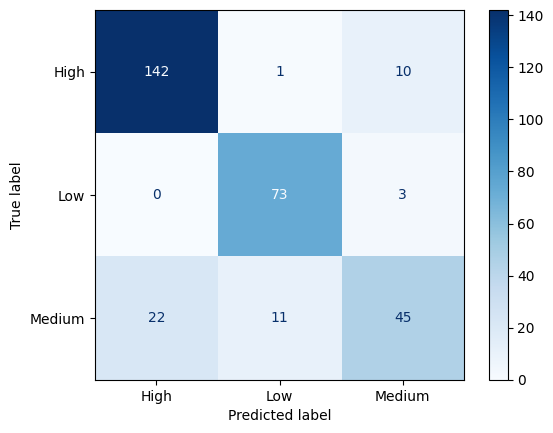

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=encoder.classes_)

disp.plot(cmap='Blues')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

        High       0.87      0.93      0.90       153
         Low       0.86      0.96      0.91        76
      Medium       0.78      0.58      0.66        78

    accuracy                           0.85       307
   macro avg       0.83      0.82      0.82       307
weighted avg       0.84      0.85      0.84       307



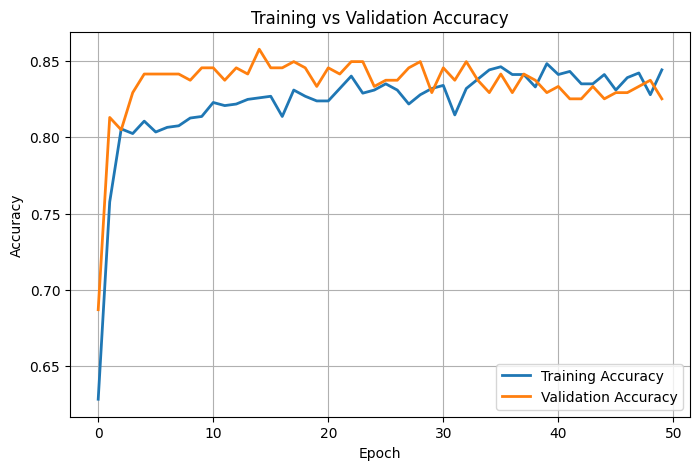

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

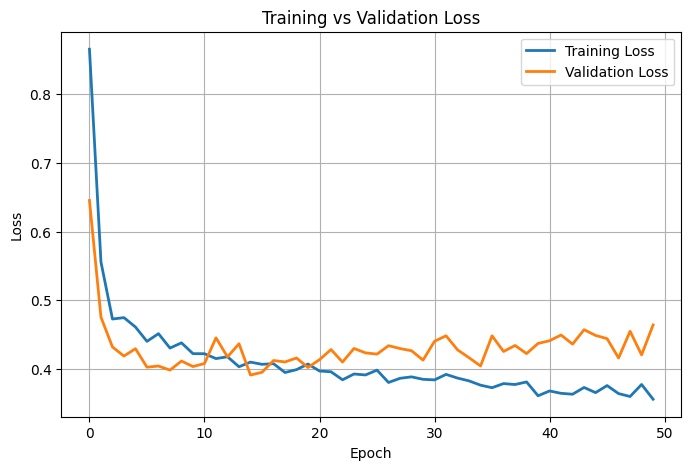

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


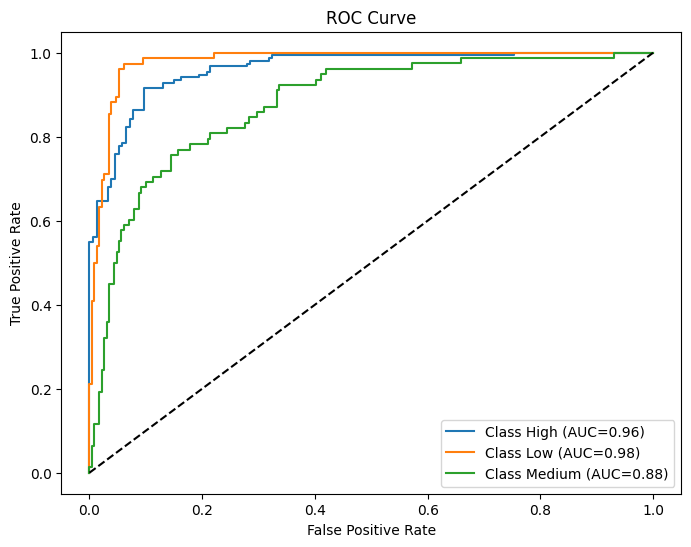

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0,1,2])

y_prob = model.predict(X_test)

plt.figure(figsize=(8,6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob[:,i])
    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,label=f'Class {encoder.classes_[i]} (AUC={roc_auc:.2f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

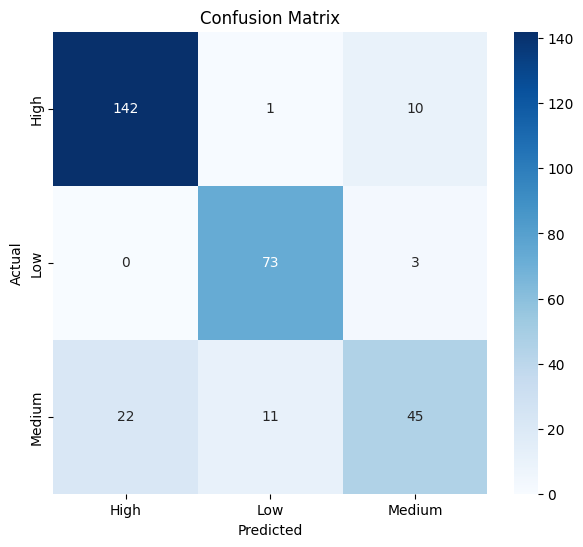

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
sample = X_test[5].reshape(1,-1)

prediction = model.predict(sample)

index = np.argmax(prediction)

print("Predicted Class :", encoder.classes_[index])

print("Confidence :", np.max(prediction)*100,"%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted Class : Low
Confidence : 99.96541 %


In [ ]:
model.save("fiat500_classifier.keras")

In [ ]:
from google.colab import files

files.download("fiat500_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

result = permutation_importance(
    mlp,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance = pd.DataFrame({
    "Feature": range(X_train.shape[1]),
    "Importance": result.importances_mean
}).sort_values("Importance", ascending=False)

print(importance.head(10))

   Feature  Importance
1        1    0.273290
2        2    0.214658
7        7    0.016612
5        5    0.014332
6        6    0.007818
8        8    0.003909
0        0    0.001954
4        4   -0.004886
3        3   -0.004886


In [ ]:
print("Neural Network Accuracy : {:.2f}%".format(accuracy*100))

Neural Network Accuracy : 84.69%
